# Quickstart (strict regression notebook)

A tiny, fully deterministic end-to-end run of `fgvb` used as a **strict** (`--nbval`) regression test: every checked cell below emits only structurally stable output (shapes, column/index labels, and boolean identity checks). The single cell that prints platform-dependent floating-point values is marked `# NBVAL_IGNORE_OUTPUT` so the strict comparison stays robust across BLAS backends. See `tutorial.ipynb` for the narrated walkthrough.

In [1]:
import numpy as np
import pandas as pd

import fgvb

# Fully deterministic synthetic dataset: a latent space that is a linear
# mixture of three feature groups (shape / texture / intensity) plus noise.
rng = np.random.default_rng(0)
n = 200
feature_names = [
    "shape_0", "shape_1",
    "texture_0", "texture_1",
    "intensity_0", "intensity_1",
]
F = rng.normal(size=(n, len(feature_names)))
df_feat = pd.DataFrame(F, columns=feature_names)
feat_to_group = {name: name.split("_")[0] for name in feature_names}

d = 4
mixing = rng.normal(size=(len(feature_names), d))
Z = F @ mixing + 0.5 * rng.normal(size=(n, d))
df_latent = pd.DataFrame(Z, columns=[f"z{i}" for i in range(d)])

print(df_latent.shape, df_feat.shape)

(200, 4) (200, 6)


shap table shape: (5, 4)
johnson table shape: (5, 7)
shap columns: ['shape', 'texture', 'intensity', 'noise']
johnson columns: ['shape_0', 'shape_1', 'texture_0', 'texture_1', 'intensity_0', 'intensity_1', 'noise']
directions: ['PC0', 'PC1', 'PC2', 'PC3', 'weighted_sum']


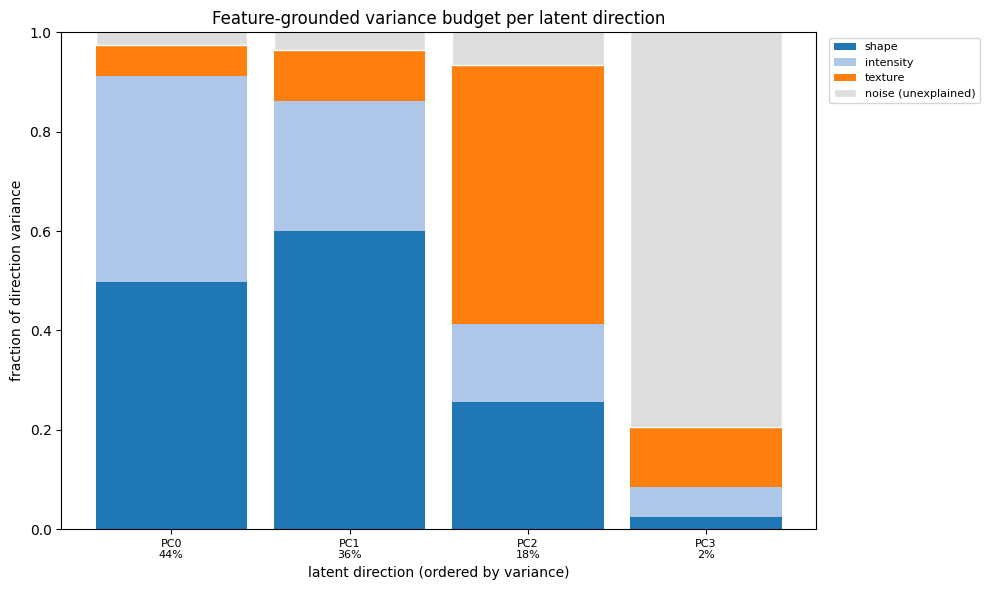

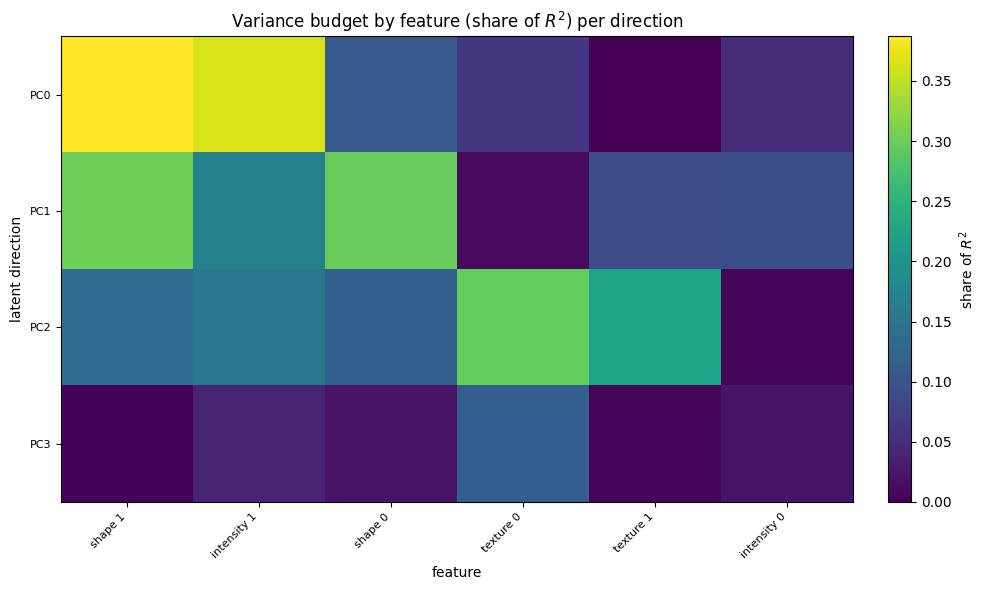

In [2]:
decomp = fgvb.FeatureGroundedDecomposition(
    df_latent, df_feat, feat_to_group, mode="eigen", cv_folds=5, seed=0,
)
shap_table, rho, _shap_fig = decomp.shap(fig_out=None)
johnson_table, _, _johnson_fig = decomp.johnson(fig_out=None)

# Only structurally-stable facts are printed (checked strictly).
print("shap table shape:", shap_table.shape)
print("johnson table shape:", johnson_table.shape)
print("shap columns:", list(shap_table.columns))
print("johnson columns:", list(johnson_table.columns))
print("directions:", list(shap_table.index))

In [3]:
# The additive-budget identities are exact, so these hold to machine precision
# regardless of platform.
assert np.allclose(shap_table.sum(axis=1), 1.0), "each SHAP row sums to 1"
assert np.allclose(johnson_table.sum(axis=1), 1.0), "each Johnson row sums to 1"
assert np.allclose(decomp.r2.values, 1.0 - shap_table["noise"].values)
assert np.allclose(decomp.r2.values, 1.0 - johnson_table["noise"].values)
assert np.isclose(decomp.r2["weighted_sum"], decomp.rho)
assert 0.0 <= decomp.rho <= 1.0
print("All additive-budget identities hold.")

All additive-budget identities hold.


In [4]:
# NBVAL_IGNORE_OUTPUT
# Platform-dependent floating-point values: shown for context, not strictly checked.
print(f"rho      = {decomp.rho:.3f}")
print(f"rho (cv) = {decomp.rho_cv:.3f}")
shap_table.round(3)

rho      = 0.950
rho (cv) = 0.942


,shape,texture,intensity,noise
direction,,,,
PC0,0.497,0.063,0.415,0.025
PC1,0.601,0.102,0.261,0.036
PC2,0.256,0.521,0.156,0.066
PC3,0.024,0.121,0.061,0.794
weighted_sum,0.482,0.163,0.306,0.050
